# 1. Basic parameters

In [43]:
import typing
import networkx as nx
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
import matplotlib.patches as mpatches

N_STATE = 20
N_ITER = 200
ITERS = np.arange(N_ITER)
ALPHA = 0.3

# 2. Define the graph topology

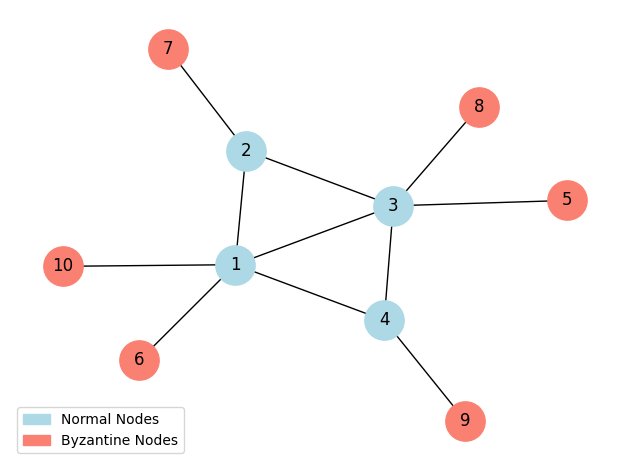

In [44]:
NORMAL_NODES = ["1", "2", "3", "4"]
NORMAL_EDGES = [
    ("1", "2"),
    ("2", "3"),
    ("3", "4"),
    ("4", "1"),
    ("1", "3"),
]
BYZANTINE_NODES = ["5", "6", "7", "8", "9", "10"]
BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "5"), ("3", "8"), ("4", "9"), ("1", "10")]

NODES = NORMAL_NODES + BYZANTINE_NODES
EDGES = NORMAL_EDGES + BYZANTINE_EDGES

N_NORMAL = len(NORMAL_NODES)
N_BYZANTINE = len(BYZANTINE_NODES)
N_NODES = N_NORMAL + N_BYZANTINE

plt.rcdefaults()

fig, ax = plt.subplots()

G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(EDGES)

pos = nx.spring_layout(G, seed=13, k=0.8)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=NORMAL_NODES,
    node_color="lightblue",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=BYZANTINE_NODES,
    node_color="salmon",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_edges(G, pos, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)

blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

ax.legend(handles=[blue_patch, red_patch], loc="lower left")
ax.axis("off")
plt.tight_layout()

# 3. Set up the cluster and run the algorithms

In [ ]:
import ray
import numpy as np
import numpy.typing as npt
import numpy.random as npr

from conops import Graph, FastNetwork


@ray.remote(num_cpus=1)
class Node:
    def __init__(
        self,
        name: str,
        neighbors: dict[str, float],
        n_state: int,
        alpha: float,
        n_iter: int,
    ) -> None:
        self.network = FastNetwork(name, neighbors)

        self.n_state = n_state
        self.alpha = alpha
        self.n_iter = n_iter

        self.upper_bound = 100.0
        self.lower_bound = -100.0

    def __ray_shutdown__(self):
        self.network.close()

    @ray.method
    def standard(self) -> npt.NDArray[np.float64]:
        network = self.network

        x = np.zeros((self.n_iter, self.n_state))
        npr.seed(int(network.node_id))  # Ensure reproducibility for each node
        x[0] = npr.uniform(self.lower_bound, self.upper_bound, self.n_state)

        for k in range(self.n_iter - 1):
            x[k + 1] = x[k] - network.laplacian(x[k]) * self.alpha

        return x

    @ray.method
    def byzantine(self) -> None:
        network = self.network
        node_id = network.node_id

        npr.seed(int(node_id))  # Ensure reproducibility for each node

        if node_id in ["8", "10"]:
            for k in range(self.n_iter - 1):
                attack_value = npr.uniform(
                    low=self.lower_bound,
                    high=self.upper_bound,
                    size=self.n_state,
                )
                _ = network.laplacian(attack_value)

        else:
            attack_values = {
                i: npr.uniform(
                    low=self.lower_bound,
                    high=self.upper_bound,
                    size=self.n_state,
                )
                for i in network.neighbors
            }

            bias = np.zeros(self.n_state)
            bias[0] = 100.0

            for k in range(self.n_iter - 1):
                n_states = network.neighborwise_exchange(attack_values)

                if k % 10 == 0:
                    for i in attack_values:
                        attack_values[i] = n_states[i] + bias
                else:
                    for i in attack_values:
                        attack_values[i] = n_states[i]

    @ray.method
    def wmsr(self) -> npt.NDArray[np.float64]:
        from arepc.baselines import WMSR

        network = self.network

        safe_handle = WMSR(network, self.alpha, f=1)

        x = np.zeros((self.n_iter, self.n_state))
        npr.seed(int(network.node_id))  # Ensure reproducibility for each node
        x[0] = npr.uniform(self.lower_bound, self.upper_bound, self.n_state)

        for k in range(self.n_iter - 1):
            # Compute new state
            x[k + 1] = safe_handle.weighted_mix(x[k])

        return x

    @ray.method
    def algorithm_with_reps(
        self, algorithm: typing.Literal["ARepC", "RepC", "WLA"]
    ) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
        network = self.network

        if algorithm == "ARepC":
            from arepc import ARepC

            safe_handle = ARepC(
                network,
                self.alpha,
                eta=0.002,
                normalization="sparsemax",
                horizon=30,
            )

        elif algorithm == "RepC":
            from arepc.baselines import RepC

            safe_handle = RepC(network, self.alpha, f=1)

        elif algorithm == "WLA":
            from arepc.baselines import WLA

            safe_handle = WLA(network, alpha=self.alpha, eta=0.001)

        else:
            raise ValueError(f"Unsupported algorithm: {algorithm}")

        x = np.zeros((self.n_iter, self.n_state))
        npr.seed(int(network.node_id))  # Ensure reproducibility for each node
        x[0] = npr.uniform(self.lower_bound, self.upper_bound, self.n_state)

        reps = {neighbor: np.zeros(self.n_iter - 1) for neighbor in network.neighbors}

        for k in range(self.n_iter - 1):
            # Compute new state
            x[k + 1] = safe_handle.weighted_mix(x[k])

            # Record normalized weights history
            r = safe_handle.reputations
            for j in network.neighbors:
                reps[j][k] = r[j]

        return x, reps


ray.init()

graph = Graph(NODES, EDGES)

nodes = {i: Node.remote(i, graph[i], N_STATE, ALPHA, N_ITER) for i in NODES}

2026-09-29 11:55:41,389	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


In [46]:
st_refs = {i: nodes[i].standard.remote() for i in NORMAL_NODES}
byz_refs = [nodes[i].byzantine.remote() for i in BYZANTINE_NODES]

st_data = {i: ray.get(ref) for i, ref in st_refs.items()}
_ = ray.get(byz_refs)

In [47]:
arepc_refs = {i: nodes[i].algorithm_with_reps.remote("ARepC") for i in NORMAL_NODES}
byz_refs = [nodes[i].byzantine.remote() for i in BYZANTINE_NODES]

arepc_data = {i: ray.get(ref) for i, ref in arepc_refs.items()}
_ = ray.get(byz_refs)

In [48]:
repc_refs = {i: nodes[i].algorithm_with_reps.remote("RepC") for i in NORMAL_NODES}
byz_refs = [nodes[i].byzantine.remote() for i in BYZANTINE_NODES]

repc_data = {i: ray.get(ref) for i, ref in repc_refs.items()}
_ = ray.get(byz_refs)

In [49]:
wmsr_refs = {i: nodes[i].wmsr.remote() for i in NORMAL_NODES}
byz_refs = [nodes[i].byzantine.remote() for i in BYZANTINE_NODES]

wmsr_data = {i: ray.get(ref) for i, ref in wmsr_refs.items()}
_ = ray.get(byz_refs)

In [50]:
wla_refs = {i: nodes[i].algorithm_with_reps.remote("WLA") for i in NORMAL_NODES}
byz_refs = [nodes[i].byzantine.remote() for i in BYZANTINE_NODES]

wla_data = {i: ray.get(ref) for i, ref in wla_refs.items()}
_ = ray.get(byz_refs)

# 4. Visualize the Results
## (1)  Standard consensus

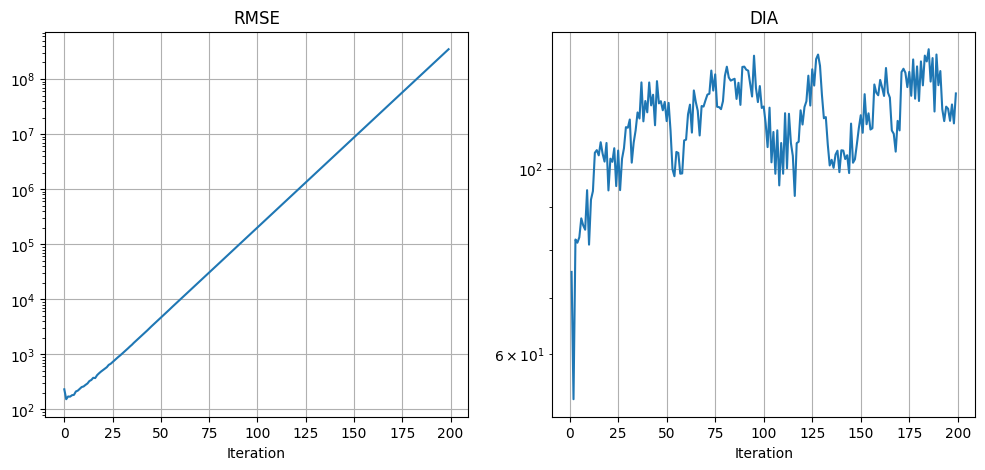

In [51]:
plt.rcdefaults()

axes: typing.Sequence[maxes.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

st_states = np.array([st_data[i] for i in NORMAL_NODES])
avg_states: npt.NDArray[np.float64] = np.average(st_states, axis=0)
diffs = st_states - avg_states
st_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

x0_mean = avg_states[0]
st_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

axes[0].semilogy(ITERS, st_rmse)
axes[0].set_xlabel("Iteration")
axes[0].set_title("RMSE")
axes[0].grid()

axes[1].semilogy(ITERS[1:], st_drift[1:])
axes[1].set_xlabel("Iteration")
axes[1].set_title("DIA")
axes[1].grid()

## (2) Reputation
### A-RepC

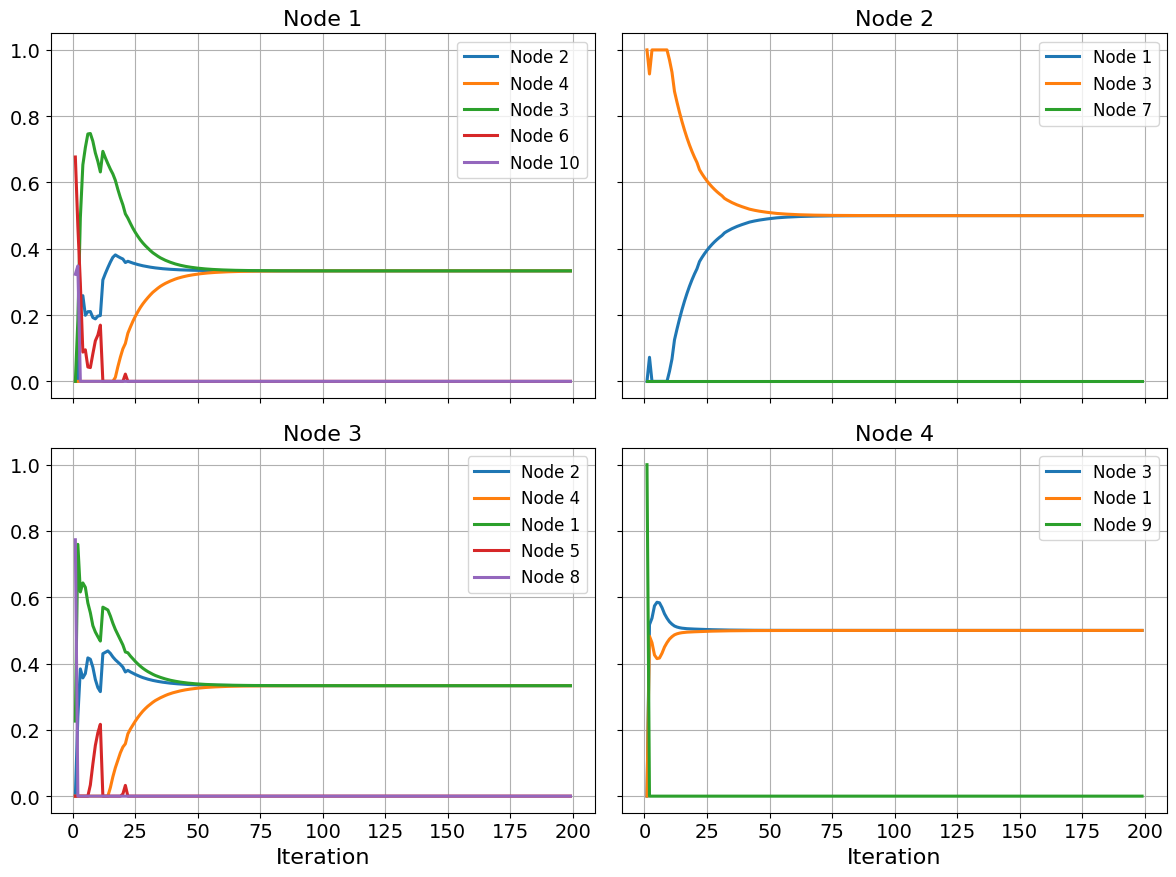

In [52]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

arepc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = arepc_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

### RepC

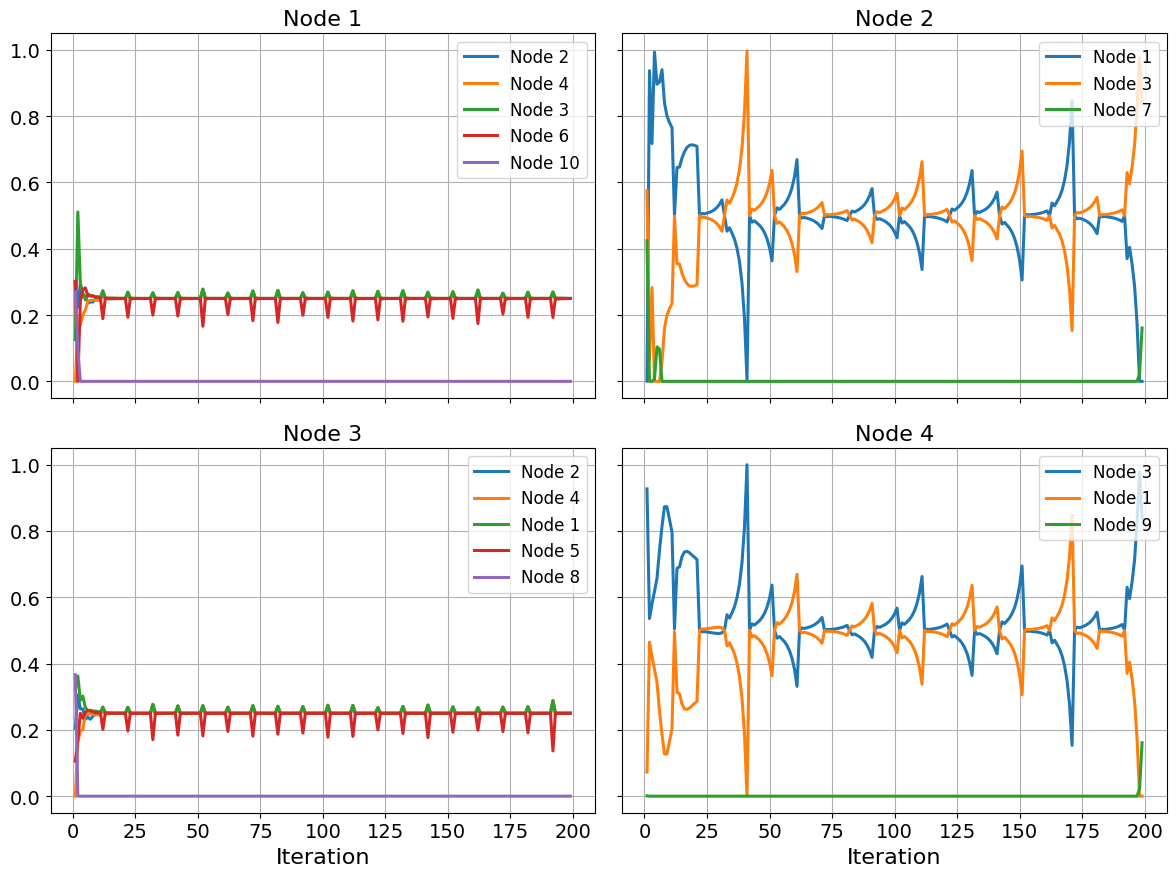

In [53]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = repc_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

### WLA

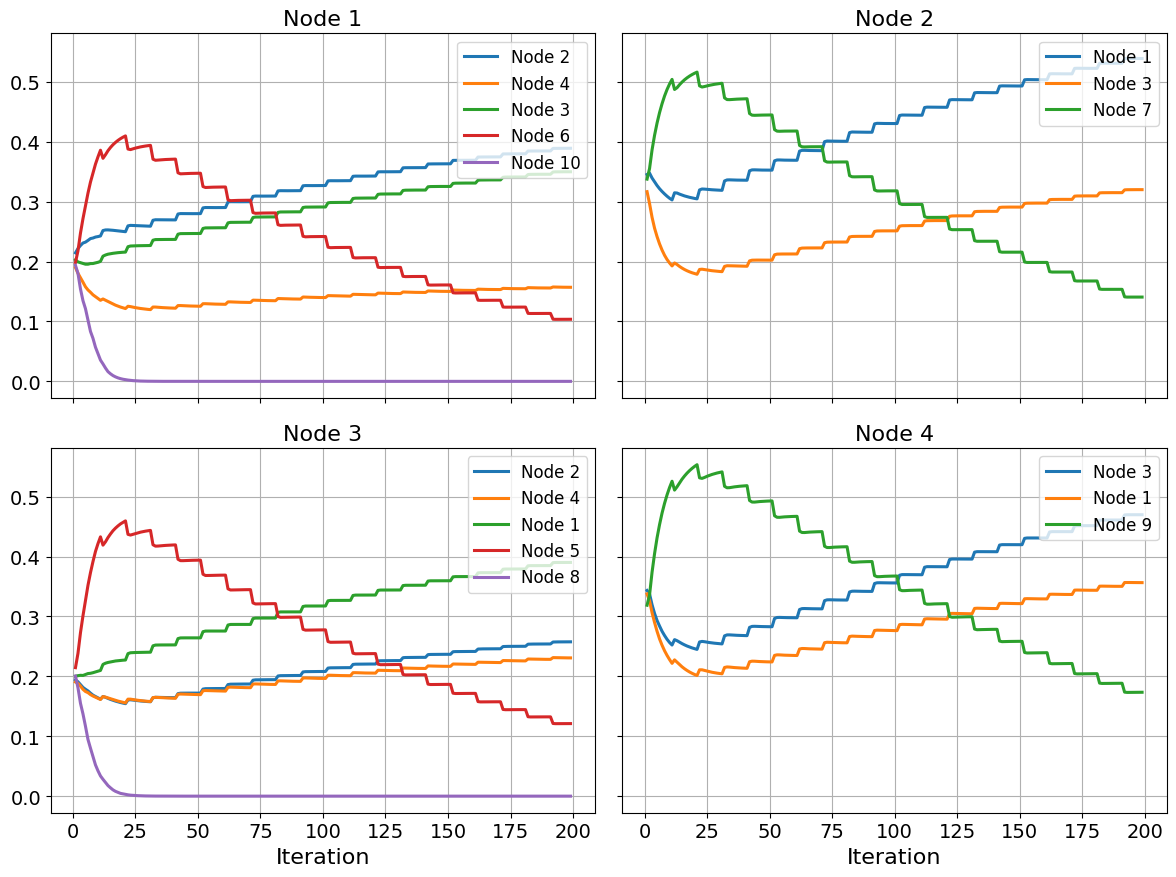

In [54]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

wla_reps = {i: wla_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = wla_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

## (3) Comparison

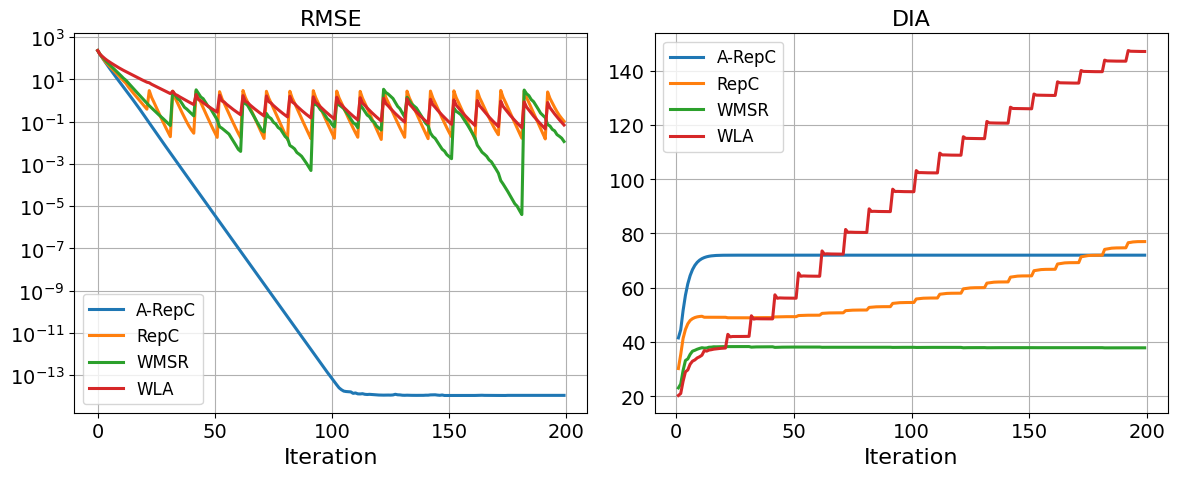

In [55]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1: maxes.Axes = axes[0]
ax2: maxes.Axes = axes[1]

arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
arepc_avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
diffs = arepc_states - arepc_avg_states
aprec_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

repc_states = np.array([repc_data[i][0] for i in NORMAL_NODES])
repc_avg_states: npt.NDArray[np.float64] = np.average(repc_states, axis=0)
diffs = repc_states - repc_avg_states
repc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

wmsr_states = np.array([wmsr_data[i] for i in NORMAL_NODES])
wmsr_avg_states: npt.NDArray[np.float64] = np.average(wmsr_states, axis=0)
diffs = wmsr_states - wmsr_avg_states
wmsr_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

wla_states = np.array([wla_data[i][0] for i in NORMAL_NODES])
wla_avg_states: npt.NDArray[np.float64] = np.average(wla_states, axis=0)
diffs = wla_states - wla_avg_states
wla_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

ax1.semilogy(ITERS, aprec_rmse, label="A-RepC")
ax1.semilogy(ITERS, repc_rmse, label="RepC")
ax1.semilogy(ITERS, wmsr_rmse, label="WMSR")
ax1.semilogy(ITERS, wla_rmse, label="WLA")
ax1.set_xlabel("Iteration")
ax1.set_title("RMSE")
ax1.legend()
ax1.grid()

fig.tight_layout()

arepc_x0_mean = arepc_avg_states[0]
aprec_drift = la.norm(arepc_avg_states - arepc_x0_mean[None, :], axis=1)

repc_x0_mean = repc_avg_states[0]
repc_drift = la.norm(repc_avg_states - repc_x0_mean[None, :], axis=1)

wmsr_x0_mean = wmsr_avg_states[0]
wmsr_drift = la.norm(wmsr_avg_states - wmsr_x0_mean[None, :], axis=1)

wla_x0_mean = wla_avg_states[0]
wla_drift = la.norm(wla_avg_states - wla_x0_mean[None, :], axis=1)

ax2.plot(ITERS[1:], aprec_drift[1:], label="A-RepC")
ax2.plot(ITERS[1:], repc_drift[1:], label="RepC")
ax2.plot(ITERS[1:], wmsr_drift[1:], label="WMSR")
ax2.plot(ITERS[1:], wla_drift[1:], label="WLA")
ax2.set_xlabel("Iteration")
ax2.set_title("DIA")
ax2.legend()
ax2.grid()

fig.tight_layout()

# 5. Shutdown the cluster

In [56]:
ray.shutdown()